# 4. Atmospheric forcing

**What this shows:** how to force SCHISM with wind and air pressure from a reanalysis,
and what the wind adds to the tide off Perth.

**Prerequisites:** [Tutorial 3: Tides and open boundaries](03_tides_and_open_boundaries.ipynb).

**You will learn:**

- how SCHISM reads atmospheric forcing (`sflux`) and how rompy-schism writes it from a
  dataset
- which variables SCHISM needs, and what happens to those your data does not have
- how to compare a model run with and without wind

**Data used:** `hgrid.gr3`, `tides/` and `era5-perth-20230101-05.nc`, ERA5 10 m wind
and mean sea-level pressure, hourly.

## Setup

In [1]:
import shutil
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import numpy as np
import xarray as xr
from rompy.backends import DockerConfig
from rompy.core.data import DataBlob
from rompy.core.filters import Filter
from rompy.core.source import SourceFile
from rompy.core.time import TimeRange
from rompy.logging import config as logging_config
from rompy.model import ModelRun

from rompy_schism.boundary_core import TidalDataset
from rompy_schism.config import SCHISMConfig
from rompy_schism.data import (
    BoundarySetupWithSource,
    SCHISMData,
    SCHISMDataBoundaryConditions,
    SCHISMDataSflux,
    SfluxAir,
)
from rompy_schism.grid import SCHISMGrid
from rompy_schism.namelists import NML, Param

logging_config.update(level="ERROR")

DATA_DIR = Path("../data")
OUT_DIR = Path("_output") / "04_atmospheric_forcing"
shutil.rmtree(OUT_DIR, ignore_errors=True)
SCHISM_IMAGE = "ghcr.io/rom-py/schism:5.13.0"
ASPECT = 1 / np.cos(np.radians(32))

## 1. The wind and pressure data

ERA5 is on a 0.25° grid, much coarser than the mesh; SCHISM interpolates it to the
nodes. In early January the wind off Perth follows the summer pattern: a morning
easterly (the land breeze) and a strong afternoon south-westerly, the sea breeze
known locally as the Fremantle Doctor.

In [2]:
era5 = xr.open_dataset(DATA_DIR / "era5-perth-20230101-05.nc")
print(era5)

<xarray.Dataset> Size: 386kB
Dimensions:    (time: 145, latitude: 17, longitude: 13)
Coordinates:
  * time       (time) datetime64[ns] 1kB 2022-12-31 ... 2023-01-06
  * latitude   (latitude) float32 68B -30.5 -30.75 -31.0 ... -34.0 -34.25 -34.5
  * longitude  (longitude) float32 52B 114.0 114.2 114.5 ... 116.5 116.8 117.0
Data variables:
    u10        (time, latitude, longitude) float32 128kB ...
    v10        (time, latitude, longitude) float32 128kB ...
    msl        (time, latitude, longitude) float32 128kB ...
Attributes:
    title:    ERA5 10 m wind and mean sea level pressure off Perth
    source:   ECMWF ERA5 reanalysis (Copernicus Climate Change Service), via ...


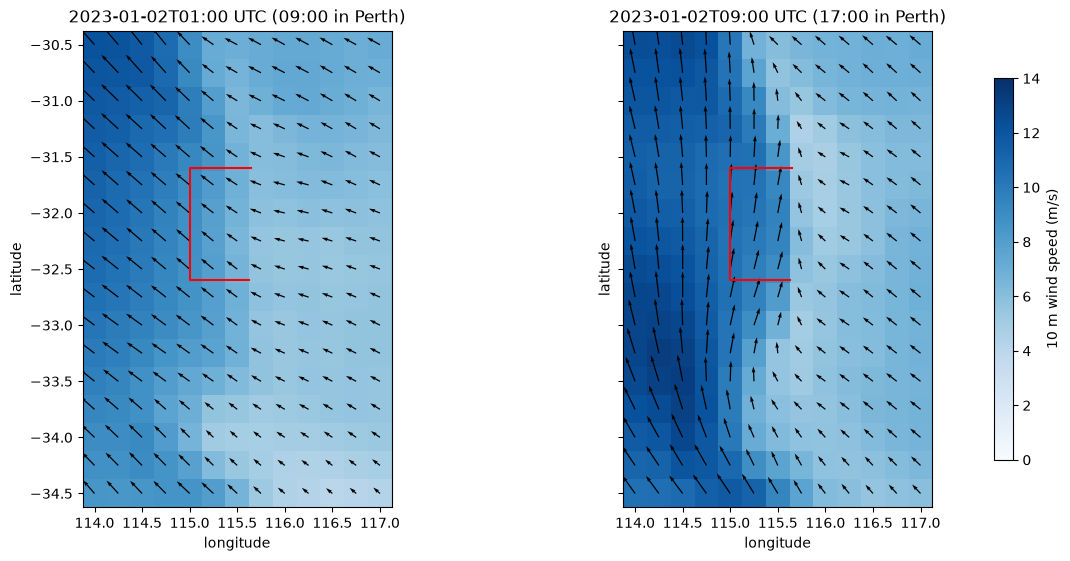

In [3]:
grid = SCHISMGrid(hgrid=DataBlob(source=DATA_DIR / "hgrid.gr3"), drag=0.0025)
hgrid = grid.pylibs_hgrid
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharey=True, layout="constrained")
for ax, time in zip(axes, ["2023-01-02T01:00", "2023-01-02T09:00"]):
    snap = era5.sel(time=time)
    speed = np.hypot(snap.u10, snap.v10)
    mesh = speed.plot(ax=ax, cmap="Blues", vmin=0, vmax=14, add_colorbar=False)
    ax.quiver(snap.longitude, snap.latitude, snap.u10, snap.v10, scale=150)
    ax.plot(hgrid.x[hgrid.iobn[0]], hgrid.y[hgrid.iobn[0]], "r")
    local = np.datetime64(time) + np.timedelta64(8, "h")  # Perth is UTC+8
    ax.set(title=f"{time} UTC ({str(local)[11:16]} in Perth)", aspect=ASPECT)
fig.colorbar(mesh, ax=axes, label="10 m wind speed (m/s)", shrink=0.8)

## 2. From a dataset to sflux

SCHISM reads the atmosphere from `sflux/` files, on the grid of the source data. It
has three kinds, each with a primary set (`_1`) and an optional finer one (`_2`)
blended with it:

| Slot | Variables | Needed for |
|---|---|---|
| `air` | wind, sea-level pressure, air temperature, humidity | wind stress and pressure gradient |
| `rad` | long- and short-wave radiation | heat exchange (`ihconsv=1`) |
| `prc` | precipitation | freshwater input |

`SfluxAir` describes one air source: the dataset and which of its variables are the
wind and pressure. Like other rompy data sources, it can filter the data, here
sorting the latitudes: ERA5 stores them from north to south, and SCHISM needs them
increasing.

In [4]:
air = SfluxAir(
    source=SourceFile(uri=DATA_DIR / "era5-perth-20230101-05.nc"),
    uwind_name="u10",
    vwind_name="v10",
    prmsl_name="msl",
    filter=Filter(sort={"coords": ["latitude"]}),
)
atmos = SCHISMDataSflux(air_1=air)

## 3. Two models: tides, and tides with the atmosphere

Both run from 1 to 5 January with the tide of Tutorial 3. The second adds the
atmosphere. Its output also includes the wind SCHISM used (`iof_hydro(14)`).

With atmospheric data, rompy-schism sets `nws=2`, SCHISM's switch for sflux input.
`wtiminc`, the interval at which SCHISM reads the forcing, is set here to the hourly
ERA5 step; `drampwind` ramps the wind up over a day, like the tide.

In [5]:
period = TimeRange(start="2023-01-01T00:00", end="2023-01-05T00:00", interval="1h")
tides = TidalDataset(
    tidal_database=DATA_DIR / "tides",
    tidal_model="TPXO9-perth",
    constituents=["M2", "S2", "N2", "K2", "K1", "O1", "P1", "Q1"],
    nodal_corrections=True,
)
boundary_conditions = SCHISMDataBoundaryConditions(
    tidal_data=tides,
    default_boundary=BoundarySetupWithSource(elev_type=3, vel_type=3),
)


def schism_config(atmos: SCHISMDataSflux | None) -> SCHISMConfig:
    """The tidal model of Tutorial 3, with or without the atmosphere."""
    output = {"iof_hydro__1": 1, "iof_hydro__16": 1, "iof_hydro__26": 0}
    if atmos is not None:
        output["iof_hydro__14"] = 1  # wind
    return SCHISMConfig(
        grid=grid,
        data=SCHISMData(boundary_conditions=boundary_conditions, atmos=atmos),
        nml=NML(
            param=Param(
                core={"ibc": 1, "ibtp": 0, "dt": 120.0, "nspool": 30, "ihfskip": 720},
                opt={"wtiminc": 3600.0},
                schout=output,
            )
        ),
    )


runs = {
    "tide": ModelRun(
        run_id="tide", period=period, output_dir=OUT_DIR, config=schism_config(None)
    ),
    "tide_and_wind": ModelRun(
        run_id="tide_and_wind", period=period, output_dir=OUT_DIR, config=schism_config(atmos)
    ),
}
workspaces = {name: Path(run()) for name, run in runs.items()}
workspace = workspaces["tide_and_wind"]
print(sorted(p.name for p in (workspace / "sflux").iterdir()))

['README', 'air_1.0001.nc', 'sflux_inputs.txt']


rompy-schism wrote the air data to `sflux/air_1.0001.nc`, one day longer on each side
than the run as SCHISM needs, and `sflux_inputs.txt`, which tells SCHISM the file
names and how to blend the sets. `param.nml` now has `nws = 2`:

In [6]:
print((workspace / "sflux" / "sflux_inputs.txt").read_text())
param_nml = (workspace / "param.nml").read_text().splitlines()
print("\n".join(line for line in param_nml if line.startswith(("nws", "wtiminc", "drampwind"))))

! SCHISM sflux namelist rendered from Rompy
&sflux_inputs
air_1_relative_weight=1.0,
air_2_relative_weight=99.0,
air_1_max_window_hours=120.0,
air_2_max_window_hours=120.0,
air_1_fail_if_missing=.true.,
air_2_fail_if_missing=.false.,
air_1_file='air_1',
air_2_file='air_2',
uwind_name='u10',
vwind_name='v10',
prmsl_name='msl',
stmp_name='stmp',
spfh_name='spfh',
rad_1_relative_weight=1.0,
rad_2_relative_weight=99.0,
rad_1_max_window_hours=24.0,
rad_2_max_window_hours=24.0,
rad_1_fail_if_missing=.false.,
rad_2_fail_if_missing=.false.,
rad_1_file='rad_1',
rad_2_file='rad_2',
dlwrf_name='dlwrf',
dswrf_name='dswrf',
prc_1_relative_weight=1.0,
prc_2_relative_weight=99.0,
prc_1_max_window_hours=24.0,
prc_2_max_window_hours=24.0,
prc_1_fail_if_missing=.false.,
prc_2_fail_if_missing=.false.,
prc_1_file='prc_1',
prc_2_file='prc_2',
prate_name='prate',
/

nws = 2
wtiminc = 3600.0
drampwind = 1.0


SCHISM needs five air variables: wind, pressure, air temperature and humidity.
`sflux_inputs.txt` maps them to the names in the file (`u10`, `v10` and `msl` from
ERA5). The ERA5 file has no air temperature or humidity, so rompy-schism filled them
with standard-atmosphere values (`stmp`, `spfh`). They are used
for heat exchange with the atmosphere, which this barotropic model does not compute.

In [7]:
sflux_air = xr.open_dataset(workspace / "sflux" / "air_1.0001.nc")
for name, variable in sflux_air.data_vars.items():
    if "time" in variable.dims:
        print(f"{name:5s} {float(variable.min()):10.2f} to {float(variable.max()):10.2f}")

u10       -10.04 to       6.73
v10        -5.51 to      13.51
msl    100304.10 to  101689.33
stmp      288.15 to     288.15
spfh        0.01 to       0.01


## 4. Run both

In [8]:


def docker_available() -> bool:
    """Return True if the Docker daemon can be reached."""
    try:
        return subprocess.run(["docker", "info"], capture_output=True).returncode == 0
    except FileNotFoundError:
        return False


def run_completed(workspace: Path) -> bool:
    """Check SCHISM's log: SCHISM exits with success even when it stops on an error."""
    mirror = workspace / "outputs" / "mirror.out"
    if mirror.exists() and "Run completed successfully" in mirror.read_text():
        return True
    fatal = workspace / "outputs" / "fatal.error"
    print(fatal.read_text() if fatal.exists() else "SCHISM did not finish")
    return False


backend = DockerConfig(image=SCHISM_IMAGE, executable="schism 2", mpiexec="mpirun", cpu=6)
results = {}
for name, run in runs.items():
    if docker_available():
        run.run(backend, workspace_dir=workspaces[name])
    if run_completed(workspaces[name]):
        results[name] = xr.open_mfdataset(
            sorted((workspaces[name] / "outputs").glob("out2d_*.nc")),
            data_vars="minimal", coords="minimal", compat="override",
        )  # fmt: skip
print(f"Completed: {list(results)}")

Completed: ['tide', 'tide_and_wind']


## 5. What the wind adds

The difference between the two runs is the effect of the atmosphere. The southerly
winds blow along the coast, and in the southern hemisphere the water they drive is
deflected to the left of the wind, offshore. So the water level at Fremantle drops by
a few centimetres, most in the afternoon when the sea breeze is strongest.

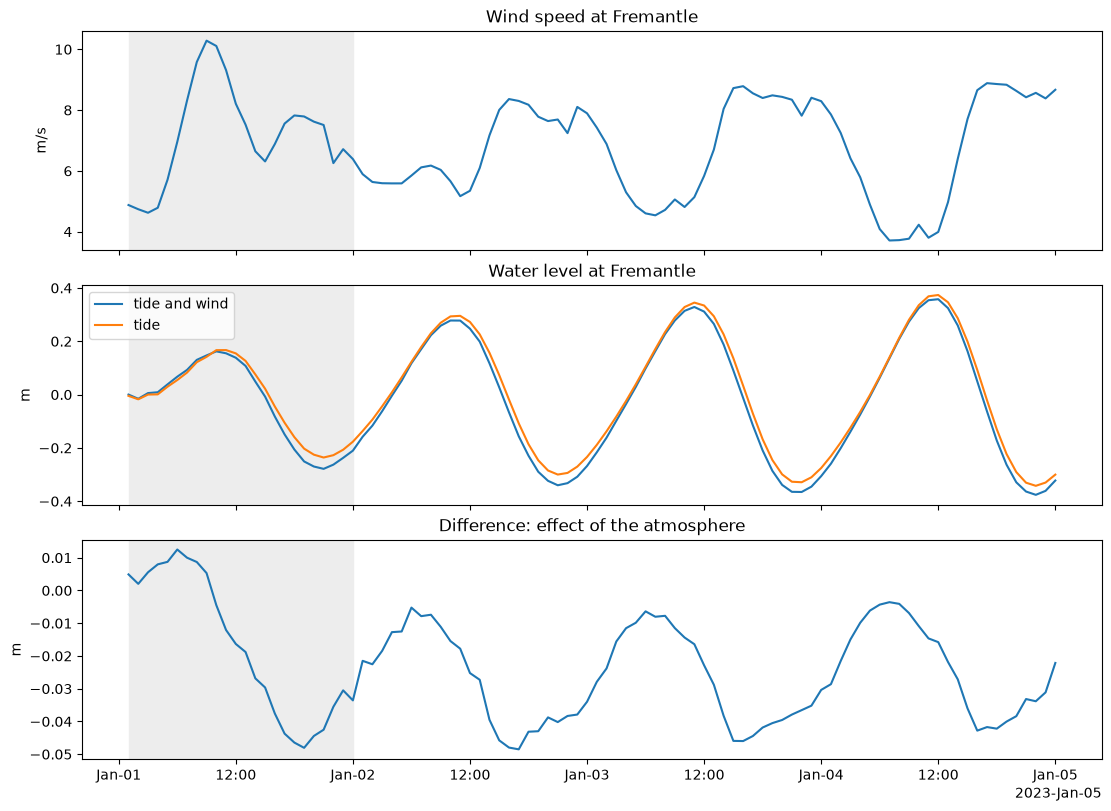

In [9]:
if len(results) == 2:
    tide, both = results["tide"], results["tide_and_wind"]
    x = both.SCHISM_hgrid_node_x.values
    y = both.SCHISM_hgrid_node_y.values
    fremantle = np.argmin((x - 115.72) ** 2 + (y + 32.06) ** 2)
    wind_speed = np.hypot(both.windSpeedX[:, fremantle], both.windSpeedY[:, fremantle])
    fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True, layout="constrained")
    wind_speed.plot(ax=axes[0])
    axes[0].set(title="Wind speed at Fremantle", ylabel="m/s", xlabel="")
    both.elevation[:, fremantle].plot(ax=axes[1], label="tide and wind")
    tide.elevation[:, fremantle].plot(ax=axes[1], label="tide")
    axes[1].set(title="Water level at Fremantle", ylabel="m", xlabel="")
    axes[1].legend()
    (both.elevation - tide.elevation)[:, fremantle].plot(ax=axes[2])
    axes[2].set(title="Difference: effect of the atmosphere", ylabel="m", xlabel="")
    for ax in axes:
        ax.axvspan(both.time[0].values, np.datetime64("2023-01-02"), color="0.93")

The wind drives currents much stronger than the tide's. Averaged over a day, which
removes most of the tide, the currents flow north under the prevailing southerly
winds, and fastest in the shallows and around the islands.

The fast current in the south-east corner is not real. The open boundary prescribes
the tide only, so the wind-driven flow along the coast cannot pass it and turns where
the boundary meets the coast. Prescribing tidal elevations only is worse here: the
boundary then holds the water level at the tide while the wind lowers it inside,
which drives spurious currents all along the boundary. The usual remedies are a
larger domain, so the boundary is far from the area of interest, or boundary
conditions from an ocean model that includes the wind, as in
[Ocean boundaries](../examples/ocean_boundaries.ipynb).

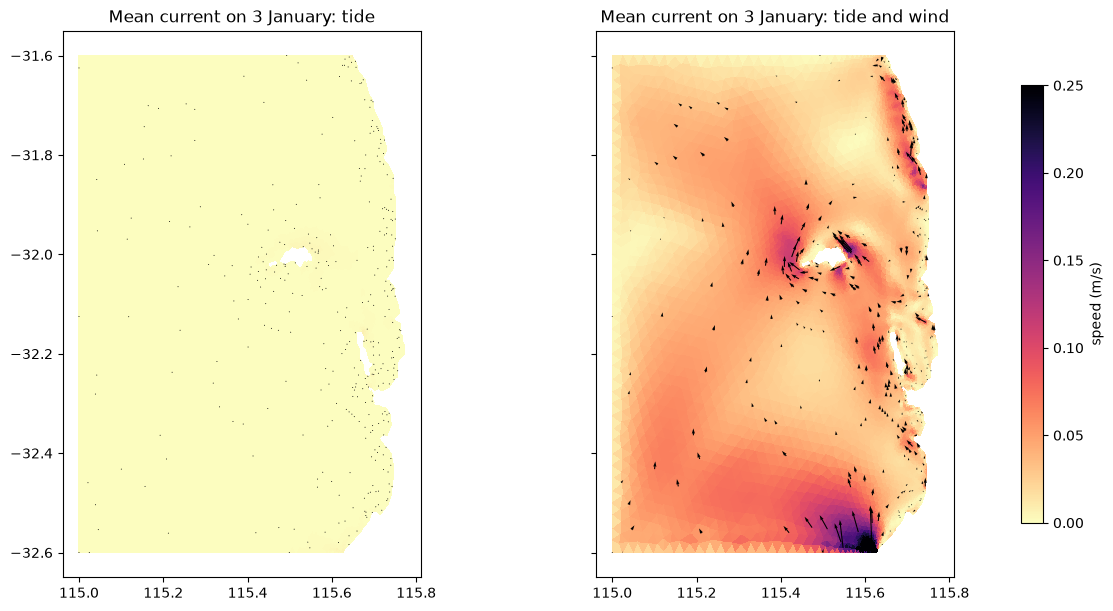

In [10]:
if len(results) == 2:
    day = slice("2023-01-03", "2023-01-03T23:59")
    triangulation = mtri.Triangulation(
        x, y, both.SCHISM_hgrid_face_nodes.values[:, :3] - 1
    )
    fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True, layout="constrained")
    for ax, (name, out) in zip(axes, [("tide", tide), ("tide and wind", both)]):
        u = out.depthAverageVelX.sel(time=day).mean("time").values
        v = out.depthAverageVelY.sel(time=day).mean("time").values
        tpc = ax.tripcolor(triangulation, np.hypot(u, v), cmap="magma_r", vmin=0, vmax=0.25)
        ax.quiver(x[::20], y[::20], u[::20], v[::20], scale=3, width=0.003)
        ax.set(title=f"Mean current on 3 January: {name}", aspect=ASPECT)
    fig.colorbar(tpc, ax=axes, label="speed (m/s)", shrink=0.8)

## Summary

- `SfluxAir` turns a dataset with wind and pressure into SCHISM's `sflux/air` files;
  `SCHISMDataSflux` holds the air, radiation and precipitation sources.
- rompy-schism writes the files for the run period plus a day on each side, fills
  missing air variables with standard values, and sets `nws=2`.
- Set `wtiminc` to the time step of the atmospheric data.
- Off Perth in summer, the southerly sea breeze lowers the water level at the coast
  by a few centimetres and drives currents stronger than the tidal ones.
- An open boundary with the tide only does not know about the wind-driven flow:
  keep it away from the area of interest, or use an ocean model at the boundary.

**Next:** [5. Choosing model settings](05_model_settings.ipynb).